In [1]:
from itertools import product
import pickle
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from popsummary.popresult import PopulationResult
from astropy.cosmology import Planck15
from astropy import units as u
import popsummary
import plot_funcs_bbh_mass as pf


plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14
plt.rcParams["text.usetex"] = True

In [2]:
def q_flat(x):
    ans=1/(5-(-15))

    return ans


def kl_divergence_kde_p_known_q(p_samples, q_pdf, base=np.e, bandwidth='scott'):
    """
    Estimate KL divergence D_KL(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated KL divergence D_KL(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde = gaussian_kde(p_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde(p_samples)
    q_vals = q_pdf(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_vals = np.clip(q_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_vals)
    kl = np.mean(log_ratio)

    return kl / np.log(base)


def kl_divergence_kde(p_samples, q_samples, base=np.e, bandwidth='scott'):
    """
    Estimate delta divergence D_delta(P || Q) where:
      - P is known via samples (estimated with KDE)
      - Q is known via samples (estimated with KDE)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_samples (array): 1D array of samples from Q
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated delta divergence D_delta(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde_p = gaussian_kde(p_samples, bw_method=bandwidth)

    q_samples = np.asarray(q_samples)
    kde_q = gaussian_kde(q_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde_p(p_samples)
    q_kde_vals = kde_q(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_kde_vals = np.clip(q_kde_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_kde_vals)
    delta = np.mean(log_ratio)

    return delta / np.log(base)

## Use LVK population analysis results as `true' population

In [3]:
gwtc4 = '/home/tristan-bruel/Documents/Science/LVK/gwtc4'
zeval = 0.2
color1 = '#FE6100'

gwtc4_pop_file = os.path.join(gwtc4, 'data_release/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5')

bptp_o4 = popsummary.popresult.PopulationResult(gwtc4_pop_file)
bptp_m1, bptp_m1_pdfs = pf.get_params(bptp_o4, 'mass_1', rate=True)
bptp_q, bptp_q_pdfs = pf.get_params(bptp_o4, 'mass_ratio')
z_list_gwtc4, R_z_gwtc4 = bptp_o4.get_rates_on_grids('redshift')
z_list_gwtc4 = z_list_gwtc4[0]

opening existing popsummary file: /home/tristan-bruel/Documents/Science/LVK/gwtc4/data_release/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5


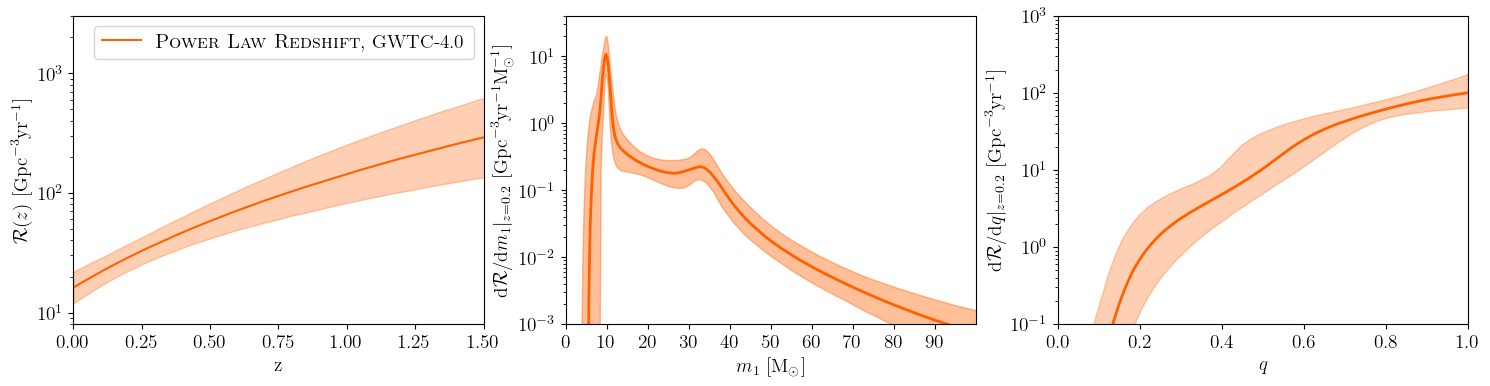

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))

# Merger rate with redshift #
ax = axes[0]
ax.fill_between(z_list_gwtc4, np.percentile(R_z_gwtc4, 5, axis=0), np.percentile(R_z_gwtc4, 95, axis=0), 
                color=color1, alpha=0.3,
               )
ax.plot(z_list_gwtc4, np.percentile(R_z_gwtc4, 50, axis=0), 
        color=color1, 
        label='\\textsc{Power Law Redshift}, GWTC-4.0',
       )

ax.set_xlabel('z')
ax.set_xlim(xmin=0, xmax=1.5)
ax.set_ylabel(r'$\mathcal{R}(z)\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=8, ymax=3e3)
ax.legend()

# Primary mass #
ax = axes[1]
pf.plot_90CI(ax, bptp_m1, bptp_m1_pdfs, 
             color=color1,  fill_alpha=0.4,
             label=r'\textsc{Broken Power Law + 2 Peaks}, \textsc{GWTC-4.0}',
            )
ax.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
ax.set_xlim(xmin=0, xmax=100)
ax.set_xticks(np.linspace(0,90,10))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=0.2}\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_\odot^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1e-3, ymax=4e1)
#ax.legend(loc='upper right', frameon=False)

# Mass ratio #
ax = axes[2]
pf.plot_90CI(ax, bptp_q, bptp_q_pdfs, 
             color=color1, 
             label=r'\textsc{Broken Power Law + 2 Peaks}, \textsc{GWTC-4.0}',
            )
ax.set_xlabel(r'$q$')
ax.set_xlim(xmin=0, xmax=1)
ax.set_xticks(np.linspace(0,1,6))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=0.2}\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1e-1, ymax=1e3)
#ax.legend(loc='upper left', frameon=False)


plt.show()
plt.close()

In [5]:
zeval=0.2
print('R(z=%.2f), integral dR/dm1, integral dR/dq' %zeval)
for ind in range(3):
    Rzeval = interp1d(z_list_gwtc4, R_z_gwtc4[ind,:], fill_value='extrapolate')(zeval)
    int_dRdm1 = np.trapezoid(x=bptp_m1, y=bptp_m1_pdfs[ind])
    int_dRdq = np.trapezoid(x=bptp_q, y=bptp_q_pdfs[ind])
    print(Rzeval, int_dRdm1, int_dRdq)

R(z=0.20), integral dR/dm1, integral dR/dq
27.257799811710818 26.866281650613274 26.866281650613274
32.611186315111446 32.60161102532506 32.60161102532506
37.241701549217375 37.241751126978336 37.24175112697835


### GW events

In [6]:
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "cos_tilt_1", "cos_tilt_2"]

data_file = np.load("./gwtc4_samples.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
num_events = int(data_file["nevents"])
num_samples = int(data_file["nsamples"])
event_priors = data_file["priors"]
print(
        f"Running with {num_events} events × {num_samples} samples = {num_events*num_samples} total samples"
    )

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

Running with 153 events × 3194 samples = 488682 total samples


### Triangulation setup

In [7]:
z_min = 1e-6
z_max = 2.0
m1_min = 3.0
m1_max = 150.0
q_min = 0.
q_max = 1.

w_min = -20
w_max = 15
nvertices_min = 4
nvertices_max = 100

corners = np.array([ 
        [m1_min, z_min, q_min],
        [m1_min, z_min, q_max],
        [m1_min, z_max, q_min],
        [m1_min, z_max, q_max],
        [m1_max, z_min, q_min],
        [m1_max, z_min, q_max],
        [m1_max, z_max, q_min], 
        [m1_max, z_max, q_max],
    ])

print(corners)

[[3.0e+00 1.0e-06 0.0e+00]
 [3.0e+00 1.0e-06 1.0e+00]
 [3.0e+00 2.0e+00 0.0e+00]
 [3.0e+00 2.0e+00 1.0e+00]
 [1.5e+02 1.0e-06 0.0e+00]
 [1.5e+02 1.0e-06 1.0e+00]
 [1.5e+02 2.0e+00 0.0e+00]
 [1.5e+02 2.0e+00 1.0e+00]]


## Some diagnostics of the sampling

In [8]:
backend_file = 'outdir0/backend'
with open(backend_file, "rb") as f:
    back = pickle.load(f)
ntemps = back.ntemps
nwalkers = back.nwalkers
nsteps = back.chain['tri'].shape[0]
tri_sizes = np.array([
        back.inds["tri"][step, 0, walker].sum()
        for step, walker in product(range(nsteps), range(nwalkers))
        ])

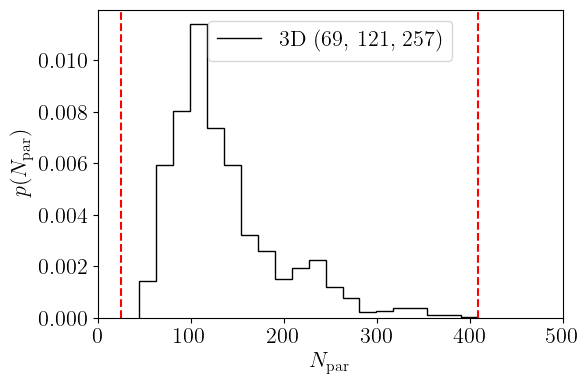

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
ax.set(
    yscale="linear",
    xlabel=r"$N_{\mathrm{par}}$",
    ylabel=r"$p(N_{\mathrm{par}})$",
    xlim=(0, 500),
)

ls = ["-", "--", ":"]

ind=0
ndim=3
offset=2**ndim

n_params = tri_sizes * (ndim + 1) + offset + 1

l, m, h = np.quantile(n_params, [0.05, 0.5, 0.95]).astype(int)

hist, edges = np.histogram(n_params, density=True, bins=20)
ax.stairs(
    hist,
    edges, 
    color='black', 
    ls=ls[ind], 
    label=f"{ndim}D ({l}, {m}, {h})"
)

ax.axvline(nvertices_min * (ndim + 1) + offset + 1, color='r', linestyle='--')
ax.axvline(nvertices_max * (ndim + 1) + offset + 1, color='r', linestyle='--')

ax.legend()
plt.show()
plt.close()

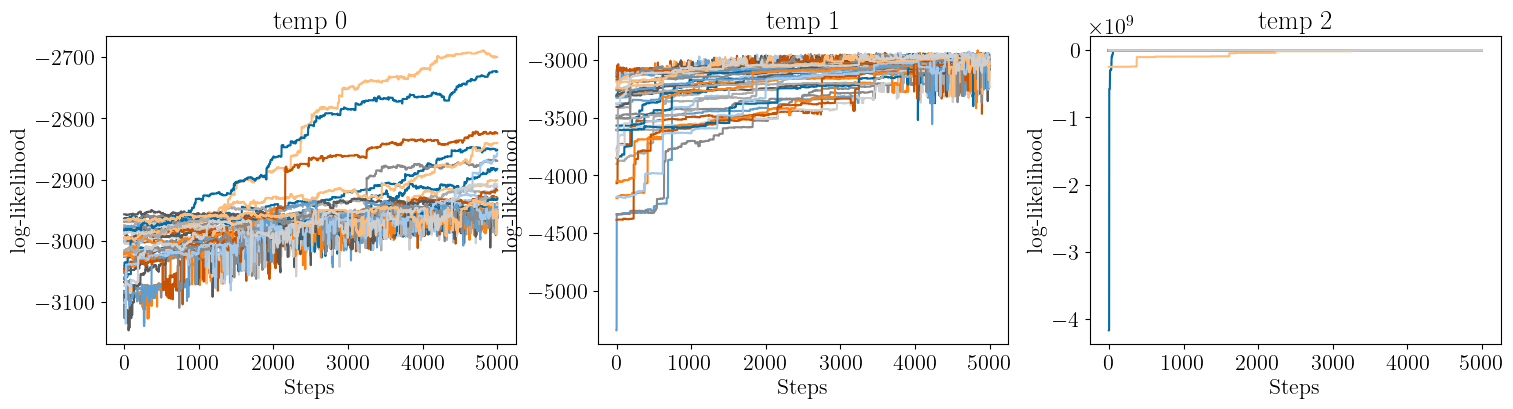

In [10]:
fig, axes = plt.subplots(1, ntemps, figsize=(18,4))
for t,w in product(range(ntemps),range(nwalkers)):
    ax = axes[t]
    ax.plot(back.get_log_like()[:, t, w])
    ax.set(title=f"temp {t}")
    ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-likelihood")
plt.show()
plt.close()

In [11]:
nburn = 1500

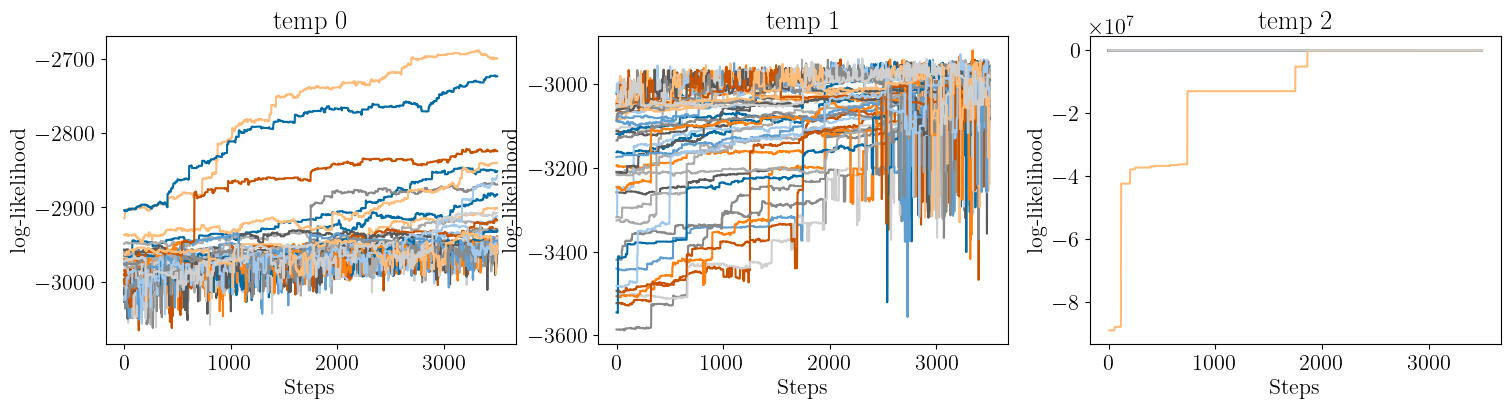

In [12]:
fig, axes = plt.subplots(1, ntemps, figsize=(18,4))
for t,w in product(range(ntemps),range(nwalkers)):
    ax = axes[t]
    ax.plot(back.get_log_like()[nburn:, t, w])
    ax.set(title=f"temp {t}")
    ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-likelihood")
plt.show()
plt.close()

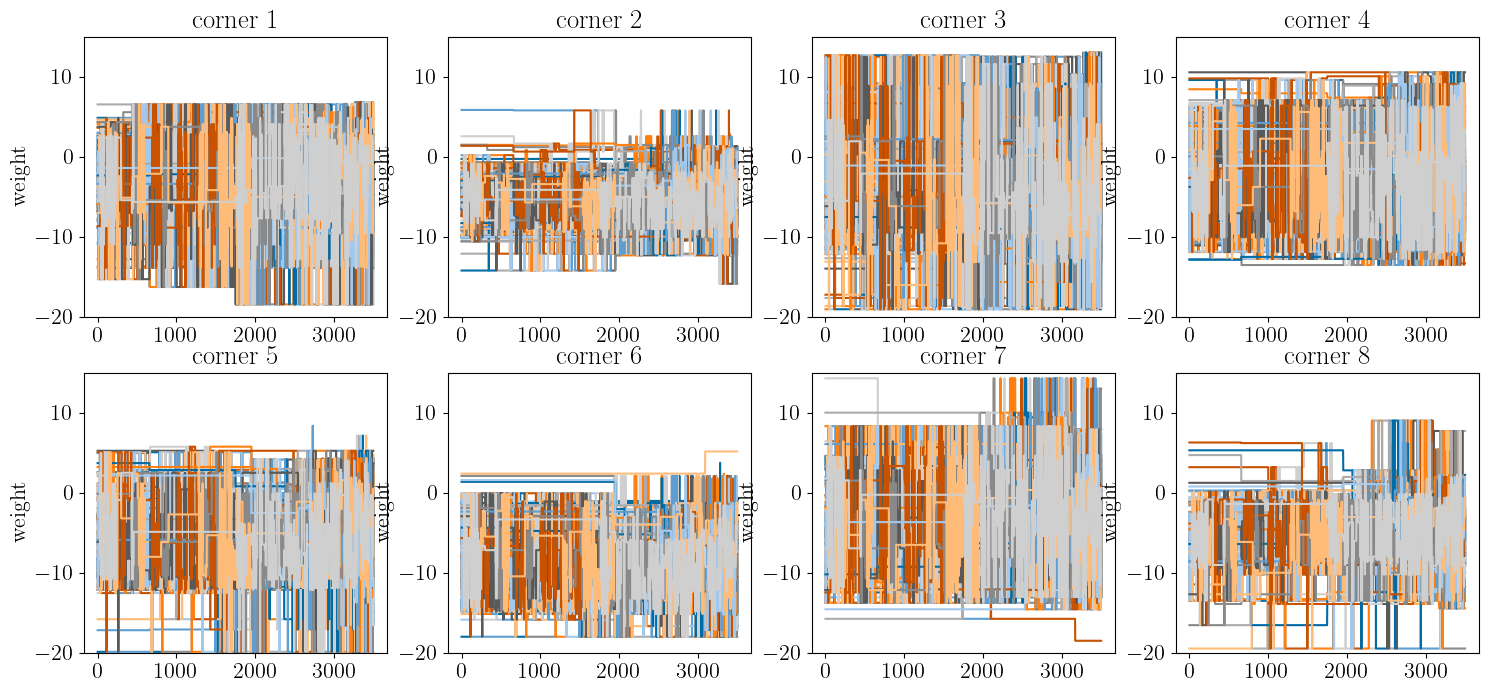

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
for n in range(len(corners)):
    ax = axes[n//4, n%4]
    for t,w in product(range(ntemps-1),range(nwalkers)):
        ax.plot(np.ravel(back.chain['corner_w'][nburn:,t,w,0,n]))
    # t=0
    # for w in range(nwalkers):
    #     ax.plot(np.ravel(back.chain['corner_w'][nburn:,t,w,0,n]))
    ax.set(title=f"corner {n+1}")
    #ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"weight")
    ax.set_ylim(w_min,w_max)
plt.show()
plt.close()

## Load triangulations

In [14]:
all_triangulations = []
# for t in range(ntemps-1):
#     triangulations = [
#         back.chain["tri"][step, t, walker][back.inds["tri"][step, t, walker]]
#         for step, walker in product(range(nburn,nsteps), range(nwalkers))
#     ]
#     corner_weights = np.array(
#         [
#             back.chain["corner_w"][step, t, walker]
#             for step, walker in product(range(nburn,nsteps), range(nwalkers))
#         ]
#     )
#     for ind in tqdm(range(len(triangulations))):
#         all_triangulations.extend([
#             np.vstack([triangulations[ind], np.c_[corners, corner_weights[ind].T]])                
#         ])
### KEEP ONLY FIRST TEMPERATURE FOR NOW ###
t=0
triangulations = [
    back.chain["tri"][step, t, walker][back.inds["tri"][step, t, walker]]
    for step, walker in product(range(nburn,nsteps), range(nwalkers))
]
corner_weights = np.array(
    [
        back.chain["corner_w"][step, t, walker]
        for step, walker in product(range(nburn,nsteps), range(nwalkers))
    ]
)
for ind in tqdm(range(len(triangulations))):
    all_triangulations.extend([
        np.vstack([triangulations[ind], np.c_[corners, corner_weights[ind].T]])                
    ])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 140000/140000 [00:00<00:00, 198244.22it/s]


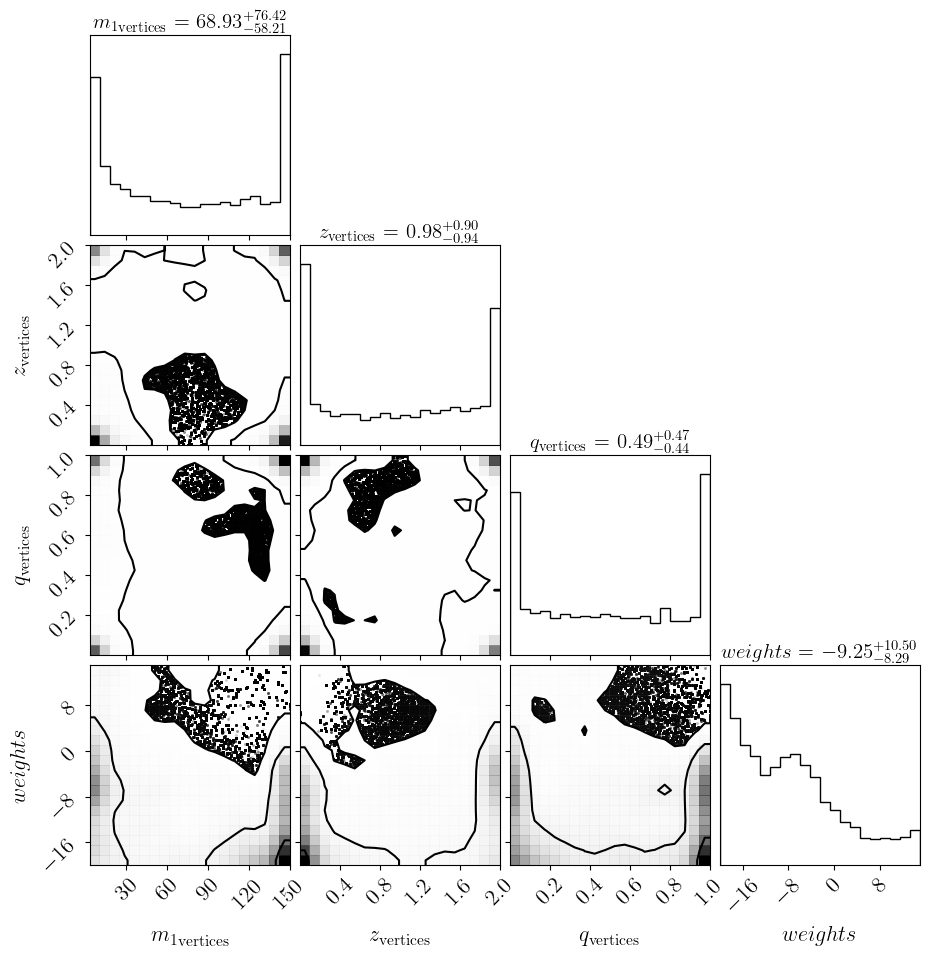

In [15]:
ws = np.hstack([tri[:, -1] for tri in all_triangulations])
vertices = np.vstack([tri[:, :-1] for tri in all_triangulations])    
corner_plot(np.c_[vertices, ws], smooth=True, levels=[0.05, 0.5, 0.95],
            labels=[r"${m_1}_\mathrm{vertices}$", r"$z_\mathrm{vertices}$", r"$q_\mathrm{vertices}$", r"$weights$"],
            show_titles=True,
            title_kwargs={"fontsize": 15},
           )
plt.show()
plt.close()

In [16]:
## Evolution of the inferred rate at fixed points ##
targets = np.array([[10.,0.2,0.8],[35.,0.2,0.8],[35.,1.0,0.8],[35.,0.2,0.5]])
selected_tris = np.random.choice(len(all_triangulations), size=1000, replace=False)
num_triangulations = len(selected_tris)

log_rate_at_target = np.zeros((num_triangulations,4))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_at_target[ind] = this_delo.interpolate(targets)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1154.02it/s]


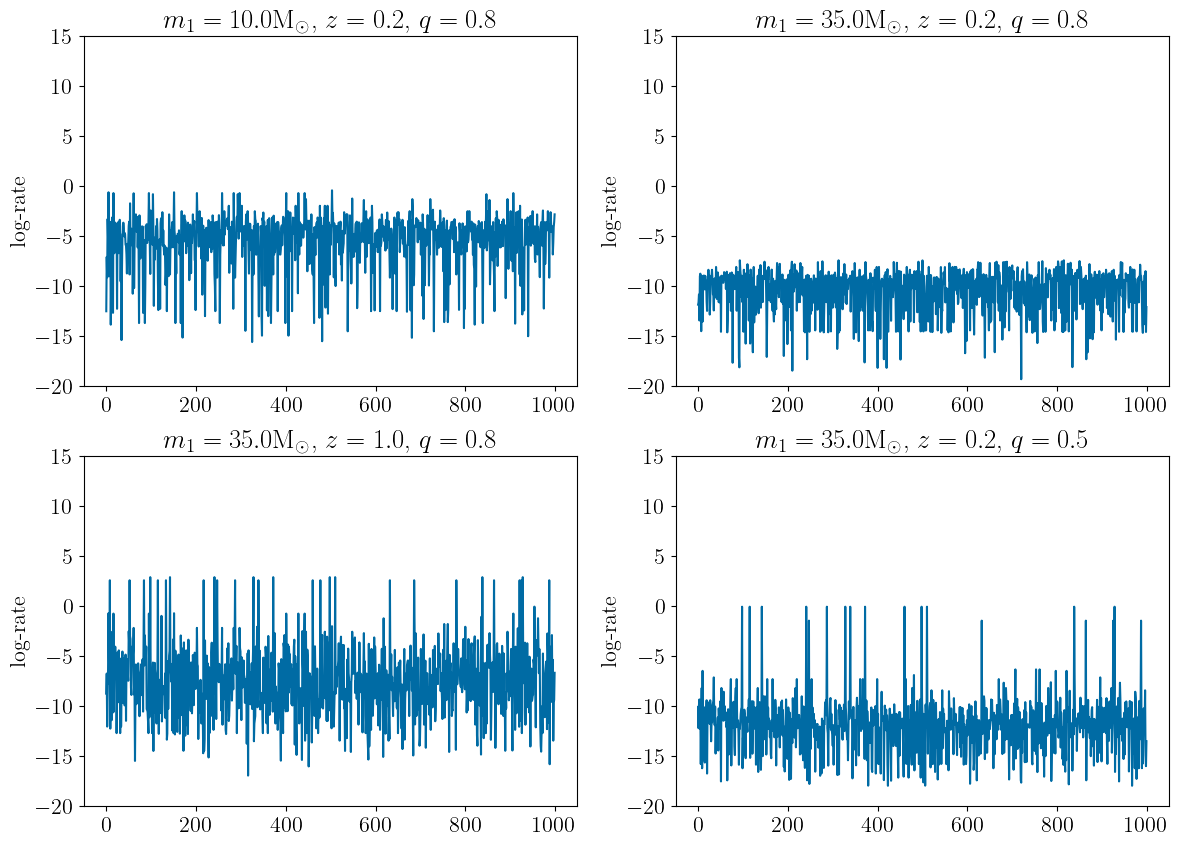

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for n in range(len(targets)):
    ax = axes[n//2, n%2]
    ax.plot(log_rate_at_target[:,n])
    ax.set(title=r"$m_1=%.1f\mathrm{M}_\odot$, $z=%.1f$, $q=%.1f$" 
           %(targets[n][0],targets[n][1],targets[n][2]))
    #ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-rate")
    ax.set_ylim(w_min,w_max)
plt.show()
plt.close()

## Compute rate over grids

In [18]:
Tobs = 2.123025832129186 # in years

In [19]:
m1_grid = np.linspace(m1_min, m1_max, 49)
z_grid = np.linspace(0.1, z_max, 50)
q_grid = np.linspace(q_min, q_max, 51)

X, Y, Z = np.meshgrid(m1_grid, z_grid, q_grid)
grid = np.c_[X.ravel(), Y.ravel(), Z.ravel()]

dm1 = m1_grid[1] - m1_grid[0]
dz = z_grid[1] - z_grid[0]
dq = q_grid[1] - q_grid[0]

to_comoving_volume = (1 + z_grid) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value
    )

In [20]:
# selected_tris = range(0, len(all_triangulations), 40)
selected_tris = np.random.choice(len(all_triangulations), size=1000, replace=False)
num_triangulations = len(selected_tris)

log_rate = np.zeros((num_triangulations, grid.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate[ind] = this_delo.interpolate(grid)
    
square_rate = log_rate.reshape(num_triangulations, z_grid.shape[0], m1_grid.shape[0], q_grid.shape[0])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:26<00:00, 37.51it/s]


In [21]:
median = np.quantile(square_rate, 0.5, axis=0)
low = np.quantile(square_rate, 0.05, axis=0)
high = np.quantile(square_rate, 0.95, axis=0)

### Injections

In [22]:
injections_file = np.load("./gwtc4_injections_full.npz")
detected_injections = np.vstack(
    [injections_file[key + "s"] for key in parameter_keys]
).T
injection_priors = injections_file["inj_priors"]
num_injections = injections_file["ninjs"]

## Prior

In [23]:
nsamples_prior = 1_000
log_rate_prior = np.zeros((nsamples_prior, grid.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+offset,ndim+1))
    tri_i[:offset,:-1] = corners
    tri_i[offset:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[offset:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[offset:,2] = np.random.uniform(q_min, q_max, nleaves_i)
    tri_i[:,-1] = np.random.uniform(w_min, w_max, nleaves_i+offset)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior[i] = this_delo.interpolate(grid)

square_rate_prior = log_rate_prior.reshape(nsamples_prior, z_grid.shape[0], m1_grid.shape[0], q_grid.shape[0])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:25<00:00, 38.73it/s]


In [ ]:
Nevents_prior = np.sum(np.exp(square_rate_prior) *to_comoving_volume[None,:,None,None], axis=(1,2,3)) *dm1 *dz *dq
median_prior = np.quantile(Nevents_prior, 0.5)
low_prior = np.quantile(Nevents_prior, 0.05)
high_prior = np.quantile(Nevents_prior, 0.95)

# Marginals

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

z_values_toplot = [0.2,0.5]
ymins = [1e-8, 1e-8]
ymaxs = [1e4, 1e4]

for n,zeval in enumerate(z_values_toplot):
    ax = axes[n]
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    pf.plot_90CI(ax, bptp_m1, bptp_m1_pdfs, 
             color=color1,  fill_alpha=0.4,
             label=r'\textsc{GWTC-4.0}',
            )
    
    dRdm1_zeval = np.sum(np.exp(square_rate[:,zeval_ind,:,:]) *to_comoving_volume[zeval_ind], axis=2) *dq
    low_dRdm1 = np.quantile(dRdm1_zeval, 0.05, axis=0)
    median_dRdm1 = np.quantile(dRdm1_zeval, 0.5, axis=0)
    high_dRdm1 = np.quantile(dRdm1_zeval, 0.95, axis=0)
    
    ax.plot(m1_grid, median_dRdm1, color="royalblue")
    ax.fill_between(m1_grid, low_dRdm1, high_dRdm1,
                    color="royalblue", alpha=0.5,
                    label=r'Inferred (integrated over $q$)',
                    )

    dRdm1_prior_zeval = np.sum(np.exp(square_rate_prior[:,zeval_ind,:,:]) 
                               *to_comoving_volume[zeval_ind], axis=2) *dq
    low_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.05, axis=0)
    median_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.5, axis=0)
    high_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.95, axis=0)
    ax.plot(m1_grid, median_dRdm1_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(m1_grid, low_dRdm1_prior, high_dRdm1_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$m_1$')
    ax.set_xlim(xmin=m1_min, xmax=m1_max)
    ax.set_xticks(np.linspace(0,m1_max,int(m1_max/15)+1))
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}\mathrm{M}_\odot]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.fill_between(z_list_gwtc4, np.percentile(R_z_gwtc4, 5, axis=0), np.percentile(R_z_gwtc4, 95, axis=0), 
                color=color1, alpha=0.3,
               )
ax.plot(z_list_gwtc4, np.percentile(R_z_gwtc4, 50, axis=0), 
        color=color1, 
        label=r'\textsc{ GWTC-4.0}',
       )

Rz = np.sum(np.exp(square_rate) 
              *to_comoving_volume[None,:,None,None], axis=(2,3)) *dq *dm1
low_Rz = np.quantile(Rz, 0.05, axis=0)
median_Rz = np.quantile(Rz, 0.5, axis=0)
high_Rz = np.quantile(Rz, 0.95, axis=0)

ax.plot(z_grid, median_Rz, color="royalblue")
ax.fill_between(z_grid, low_Rz, high_Rz,
                color="royalblue", alpha=0.5,
                label=r'Inferred (integrated over $m_1$ and $q$)',
                )

Rz_prior = np.sum(np.exp(square_rate_prior) 
                    *to_comoving_volume[None,:,None,None], axis=(2,3)) *dq *dm1
low_Rz_prior = np.quantile(Rz_prior, 0.05, axis=0)
median_Rz_prior = np.quantile(Rz_prior, 0.5, axis=0)
high_Rz_prior = np.quantile(Rz_prior, 0.95, axis=0)
ax.plot(z_grid, median_Rz_prior, color="forestgreen", alpha=0.5)
ax.fill_between(z_grid, low_Rz_prior, high_Rz_prior,
                color="forestgreen", alpha=0.25,
                label='Induced prior',
                )


ax.set_xlabel(r'$z$')
ax.set_xlim(xmin=z_min, xmax=z_max)
ax.set_xticks(np.linspace(0,z_max,int(z_max*10)+1)[::2])
ax.set_ylabel(r'$\mathcal{R}(z)\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.legend(loc='best')
#ax.set_box_aspect(1)
ax.set_ylim(ymin=1e-3, ymax=1e5)

plt.show()
plt.close()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

z_values_toplot = [0.2,0.5]
ymins = [1e-6, 1e-6]
ymaxs = [1e6, 1e6]

for n,zeval in enumerate(z_values_toplot):
    ax = axes[n]
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    pf.plot_90CI(ax, bptp_q, bptp_q_pdfs, 
             color=color1, 
             label=r'\textsc{GWTC-4.0}',
            )
    
    dRdq_zeval = np.sum(np.exp(square_rate[:,zeval_ind,:,:]) 
                        *to_comoving_volume[zeval_ind], axis=1) *dm1
    low_dRdq = np.quantile(dRdq_zeval, 0.05, axis=0)
    median_dRdq = np.quantile(dRdq_zeval, 0.5, axis=0)
    high_dRdq = np.quantile(dRdq_zeval, 0.95, axis=0)
    
    ax.plot(q_grid, median_dRdq, color="royalblue")
    ax.fill_between(q_grid, low_dRdq, high_dRdq,
                    color="royalblue", alpha=0.5,
                    label=r'Inferred (integrated over $m_1$)',
                    )
    
    dRdq_prior_zeval = np.sum(np.exp(square_rate_prior[:,zeval_ind,:,:]) 
                               *to_comoving_volume[zeval_ind], axis=1) *dm1
    low_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.05, axis=0)
    median_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.5, axis=0)
    high_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.95, axis=0)
    ax.plot(q_grid, median_dRdq_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(q_grid, low_dRdq_prior, high_dRdq_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$q$')
    ax.set_xlim(xmin=q_min, xmax=q_max)
    ax.set_xticks(np.linspace(0,1,6))
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

# 95% - 5% CI 

In [ ]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for qeval in [0.2, 0.5, 0.8]:
    qeval_ind = np.argmin(np.abs(q_grid-qeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")


    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, qeval_ind] +np.log(to_comoving_volume[:,None]),
                      cmap=cmap, norm=norm,
                     )
    
    # Calculate the difference
    diff = high[:, :, qeval_ind] - low[:, :, qeval_ind]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, z_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[qeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_q = np.abs(detected_injections[:,2]-q_grid[qeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='upper right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

In [ ]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for zeval in [0.2, 0.5, 1.0]:
    zeval_ind = np.argmin(np.abs(z_grid-zeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"z = {z_grid[zeval_ind]:.1f}")   
    
    c = ax.pcolormesh(m1_grid, q_grid, median[zeval_ind, :, :].T +np.log(to_comoving_volume[zeval_ind]),
                      cmap=cmap, norm=norm,
                     )

    
    # Calculate the difference
    diff = high[zeval_ind, :, :] - low[zeval_ind, :, :]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, q_grid, diff.T, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_z = np.abs(event_barycenters[:,1]-z_grid[zeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_z,0], event_barycenters[events_at_z,2],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_z = np.abs(detected_injections[:,1]-z_grid[zeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_z,0], detected_injections[injections_at_z,2],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$q$')
    ax.legend(loc='lower right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

### LVK results in 2D

In [ ]:
# Downselect to a reasonable number of hyperparameter samples
num_pop_LVK = 50
inds = np.random.choice(np.arange(R_z_gwtc4.shape[0]), size=num_pop_LVK, replace=False)

In [ ]:
rate_pop_LVK = np.zeros((num_pop_LVK, len(z_list_gwtc4), len(bptp_m1)))
for ind,pop_ind in enumerate(tqdm(inds)):
    int_dRdm1 = np.trapezoid(x=bptp_m1, y=bptp_m1_pdfs[pop_ind])
    rate_pop_LVK[ind] = np.outer(R_z_gwtc4[pop_ind], bptp_m1_pdfs[pop_ind] /int_dRdm1)
median_LVK = np.quantile(rate_pop_LVK, 0.5, axis=0)

In [ ]:
cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=3)

fig, ax = plt.subplots(figsize=(6,6))
c = ax.pcolormesh(bptp_m1, z_list_gwtc4, np.log(median_LVK),
                  cmap=cmap, norm=norm,
                 )
cbar = fig.colorbar(c, ax=ax, fraction=0.045)
cbar.set_label(r'Median log rate - LVK')


ax.set_xlabel('$m_1$')
ax.set_xlim(m1_min, m1_max)
ax.set_ylabel('$z$')
ax.set_ylim(z_min, z_max)
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

plt.show()
plt.close()

# Delta

In [ ]:
diff = high-low
interp_delta = RegularGridInterpolator((z_grid, m1_grid, q_grid), diff, bounds_error=False, fill_value=np.nan)

In [ ]:
qeval = 0.8
qeval_ind = np.argmin(np.abs(q_grid-qeval))

cmap=plt.get_cmap('magma')
norm=mpl.colors.Normalize(vmin=np.min(diff), vmax=np.max(diff))
fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=qeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],
              c=interp_delta(samples_try[:,(1,0,2)]),
              cmap=cmap, norm=norm,
             )
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'$\Delta$')

plt.show()
plt.close()

In [ ]:
delta_levels = np.linspace(np.min(diff), np.max(diff), 20)[1:-1]
print(delta_levels)

In [ ]:
samples_per_tri = 1_000
ndraw = 10_000

ints_delta={}
ints_delta_LVK={}
volume = np.prod(corners.max(axis=0) - corners.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for delta in delta_levels:
    print(delta)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))
    cosmo_fac=np.zeros(ndraw)

    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep       
        inds_proposal_keep=np.argwhere(interp_delta(new_points[:,(1,0,2)])<delta)[:,0]
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])
        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_delta[delta]=np.zeros(num_triangulations)
    ints_delta_LVK[delta]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)
        ints_delta[delta][ind] = mean_fx * frac_kept * volume

    for n,pop_ind in enumerate(tqdm(inds)):
        int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=strong_bbh_O4b_Rm1[pop_ind])
        int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, y=strong_bbh_O4b_Rq[pop_ind])
        pdf_m1 = interp1d(x=strong_bbh_O4b_m1_grid, 
                          y=strong_bbh_O4b_Rm1[pop_ind] /int_dRdm1, 
                          fill_value="extrapolate",
                         )
        rate_z = interp1d(x=strong_bbh_O4b_z_grid, 
                          y=strong_bbh_O4b_Rz[0], 
                          fill_value="extrapolate",
                         )
        pdf_q = interp1d(x=strong_bbh_O4b_q_grid, 
                         y=strong_bbh_O4b_Rq[pop_ind] /int_dRdq, 
                         fill_value="extrapolate",
                        )
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
            *pdf_q(proposals[:,2])
        ).mean()       
        ints_delta_LVK[delta][ind] = mean_Nx * frac_kept * volume

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_delta_LVK[delta]) for delta in delta_levels]
low_LVK = [ np.quantile(ints_delta_LVK[delta], 0.05) for delta in delta_levels]
high_LVK = [ np.quantile(ints_delta_LVK[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(delta_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_delta = [ np.median(ints_delta[delta]) for delta in delta_levels]
low_delta = [ np.quantile(ints_delta[delta], 0.05) for delta in delta_levels]
high_delta = [ np.quantile(ints_delta[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_delta, label='Inferred')
ax.fill_between(delta_levels, low_delta, high_delta, alpha=0.4)

ax.errorbar(delta_levels[-1]*1.05, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower right')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()

# KL divergences

In [ ]:
m1_grid_coarse = np.linspace(m1_min, m1_max, 19)
z_grid_coarse = np.linspace(0.1, z_max, 20)
q_grid_coarse = np.linspace(q_min, q_max, 21)

X_coarse, Y_coarse, Z_coarse = np.meshgrid(m1_grid_coarse, z_grid_coarse, q_grid_coarse)
grid_coarse = np.c_[X_coarse.ravel(), Y_coarse.ravel(), Z_coarse.ravel()]

dm1_coarse = m1_grid_coarse[1] - m1_grid_coarse[0]
dz_coarse = z_grid_coarse[1] - z_grid_coarse[0]
dq_coarse = q_grid_coarse[1] - q_grid_coarse[0]

to_comoving_volume_coarse = (1 + z_grid_coarse) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid_coarse).to(u.Gpc**3 / u.sr).value
    )

In [ ]:
log_rate_coarse = np.zeros((num_triangulations, grid_coarse.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_coarse[ind] = this_delo.interpolate(grid_coarse)
    
square_rate_coarse = log_rate_coarse.reshape(num_triangulations, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0])

In [ ]:
nsamples_prior = 1_000
log_rate_prior_coarse = np.zeros((nsamples_prior, grid_coarse.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+offset,ndim+1))
    tri_i[:offset,:-1] = corners
    tri_i[offset:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[offset:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[offset:,2] = np.random.uniform(q_min, q_max, nleaves_i)
    tri_i[:,-1] = np.random.uniform(w_min, w_max, nleaves_i+offset)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior_coarse[i] = this_delo.interpolate(grid_coarse)

square_rate_prior_coarse = log_rate_prior_coarse.reshape(nsamples_prior, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0])

In [ ]:
kl_divs=np.zeros((len(z_grid_coarse),len(m1_grid_coarse),len(q_grid_coarse)))

for i,j,k in product(range(z_grid_coarse.shape[0]),range(m1_grid_coarse.shape[0]),range(q_grid_coarse.shape[0])):
    kl_divs[i,j,k] = kl_divergence_kde(square_rate_coarse[:,i,j,k],square_rate_prior_coarse[:,i,j,k])

In [ ]:
interp_kl = RegularGridInterpolator((z_grid_coarse, m1_grid_coarse, q_grid_coarse), kl_divs, bounds_error=False, fill_value=np.nan)

In [ ]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for qeval in [0.2, 0.5, 0.8]:
    qeval_ind = np.argmin(np.abs(q_grid-qeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, qeval_ind] +np.log(to_comoving_volume[:,None]),
                      cmap=cmap, norm=norm,
                     )

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    Xz0, Yz0, Zz0 = np.meshgrid(m1_grid, z_grid, np.array([q_grid[qeval_ind]]))
    # grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]
    grid_z0 = np.c_[Yz0.ravel(), Xz0.ravel(), Zz0.ravel()]

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        m1_grid, z_grid, interp_kl(grid_z0).reshape(len(z_grid),len(m1_grid)), 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours][::-1],
        linewidths=2, 
        colors='black'
    )
    ax.clabel(contours_kl, fmt="%.2f")
    ax.plot([],[], lw=2, color='k', label='KL')

    ## Overplot contours of diff log-rate ## 35
    # Calculate the difference
    diff = high[:, :, qeval_ind] - low[:, :, qeval_ind]
    # Define contour levels (choose appropriate values for your data)
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max
    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, z_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[qeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    # injections_at_q = np.abs(detected_injections[:,2]-q_grid[qeval_ind]) < 0.01
    # ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
    #            c='r', marker='d', s=4**2, zorder=1,
    #            label='Detected injections',
    #           )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='upper right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

In [ ]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for zeval in [0.2, 0.5, 1.0]:
    zeval_ind = np.argmin(np.abs(z_grid-zeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"z = {z_grid[zeval_ind]:.1f}")   
    
    c = ax.pcolormesh(m1_grid, q_grid, median[zeval_ind, :, :].T +np.log(to_comoving_volume[zeval_ind]),
                      cmap=cmap, norm=norm,
                     )

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    Xz0, Yz0, Zz0 = np.meshgrid(m1_grid, np.array([z_grid[zeval_ind]]), q_grid)
    # grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]
    grid_z0 = np.c_[Yz0.ravel(), Xz0.ravel(), Zz0.ravel()]

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        m1_grid, q_grid, interp_kl(grid_z0).reshape(len(m1_grid),len(q_grid)).T, 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours][::-1],
        linewidths=2, 
        colors='black'
    )
    ax.clabel(contours_kl, fmt="%.2f")
    ax.plot([],[], lw=2, color='k', label='KL')

    
    # Calculate the difference
    diff = high[zeval_ind, :, :] - low[zeval_ind, :, :]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, q_grid, diff.T, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_z = np.abs(event_barycenters[:,1]-z_grid[zeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_z,0], event_barycenters[events_at_z,2],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    # injections_at_z = np.abs(detected_injections[:,1]-z_grid[zeval_ind]) < 0.01
    # ax.scatter(detected_injections[injections_at_z,0], detected_injections[injections_at_z,2],
    #            c='r', marker='d', s=4**2, zorder=1,
    #            label='Detected injections',
    #           )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$q$')
    ax.legend(loc='lower right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

In [ ]:
qeval = 0.8
qeval_ind = np.argmin(np.abs(q_grid-qeval))

cmap=plt.get_cmap('magma')
norm=mpl.colors.Normalize(vmin=np.min(kl_divs), vmax=np.max(kl_divs))
fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=qeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],
              c=interp_kl(samples_try[:,(1,0,2)]),
              cmap=cmap, norm=norm,
             )
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'KL divergence')

plt.show()
plt.close()

In [ ]:
kl_levels = np.linspace(0, np.max(kl_divs), 20)[1:-1]
print(kl_levels)

In [ ]:
samples_per_tri = 1_000
ndraw = 10_000

ints_kl={}
ints_kl_LVK={}
volume = np.prod(corners.max(axis=0) - corners.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for kl in np.flip(kl_levels):
    print(kl)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))
    cosmo_fac=np.zeros(ndraw)
    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points[:,(1,0,2)])>kl)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])

        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_kl[kl]=np.zeros(num_triangulations)
    ints_kl_LVK[kl]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)        
        ints_kl[kl][ind]= mean_fx * frac_kept * volume

    for n,pop_ind in enumerate(tqdm(inds)):
        int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=strong_bbh_O4b_Rm1[pop_ind])
        int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, y=strong_bbh_O4b_Rq[pop_ind])
        pdf_m1 = interp1d(x=strong_bbh_O4b_m1_grid, 
                          y=strong_bbh_O4b_Rm1[pop_ind] /int_dRdm1, 
                          fill_value="extrapolate",
                         )
        rate_z = interp1d(x=strong_bbh_O4b_z_grid, 
                          y=strong_bbh_O4b_Rz[0], 
                          fill_value="extrapolate",
                         )
        pdf_q = interp1d(x=strong_bbh_O4b_q_grid, 
                         y=strong_bbh_O4b_Rq[pop_ind] /int_dRdq, 
                         fill_value="extrapolate",
                        )
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
            *pdf_q(proposals[:,2])
        ).mean()       
        ints_kl_LVK[kl][ind] = mean_Nx * frac_kept * volume

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_kl_LVK[delta]) for delta in kl_levels]
low_LVK = [ np.quantile(ints_kl_LVK[delta], 0.05) for delta in kl_levels]
high_LVK = [ np.quantile(ints_kl_LVK[delta], 0.95) for delta in kl_levels]

ax.plot(kl_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(kl_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_kl = [ np.median(ints_kl[kl]) for kl  in kl_levels]
low_kl = [ np.quantile(ints_kl[kl], 0.05) for kl  in kl_levels]
high_kl = [ np.quantile(ints_kl[kl], 0.95) for kl  in kl_levels]

ax.plot(kl_levels, median_kl, label='Inferred')
ax.fill_between(kl_levels, low_kl, high_kl, alpha=0.4)

ax.errorbar(0, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

ax.set_xlabel(r'KL')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower left')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()